# NucVerse3D — pretrained 3D nuclei segmentation on one Drosophila test volume (T4 GPU)

**Paper**: Jorge Vergara, Cristian Pérez-Gallardo, Ricardo Velasco, Dilan Martínez, Diego Badilla, Esteban G. Contreras, Pamela Guevara, Fabián Segovia-Miranda, Hernán Morales-Navarrete.
*NucVerse3D: Generalizable 3D nuclear instance segmentation across heterogeneous microscopy modalities.*
bioRxiv v2 (2026) doi:[10.64898/2026.02.05.704108](https://doi.org/10.64898/2026.02.05.704108); published as *Scientific Reports* doi:[10.1038/s41598-026-51994-x](https://doi.org/10.1038/s41598-026-51994-x).

**Code (author)**: [Segovia-lab/NucVerse3D](https://github.com/Segovia-lab/NucVerse3D), MIT license, pinned commit `d809a2e6cf380342708b7a9107574b259e6b34eb`.
**Data + weights (author)**: Zenodo record [10.5281/zenodo.18517324](https://doi.org/10.5281/zenodo.18517324) (v1.0): `raw.zip` (730 MB), `models.zip` (7.9 GB).

**Scope (one-example partial demonstration, executed)**: load the paper-matched pretrained checkpoint
`resunet_drosophila-denoised/best_model.weights.h5` and run the **author's own** full prediction
pipeline (`python -m nuclei_prediction`) on **one** Drosophila brain glia test volume (`C2_M01.tif`,
confocal, voxel size 0.15 × 0.15 × 0.3 µm), then compare the predicted 3D instance labels against the
released ground-truth mask `C2_M01-label.tif`. NucVerse3D predicts a binary nuclear foreground mask and
a 3D gradient field per voxel; instances are reconstructed by gradient-descent voxel grouping toward
centroids (no shape-convexity assumption).

**Out of scope**: training, the pooled/scaled generalized models, the full 6-dataset benchmark, and the
paper's Nuclear Decoupling Score (NDS) phenotyping analysis.

**Execution status**: executed end-to-end on a Google Colab **T4 GPU** runtime (see the validation record
in the final cells). CPU-only runtimes are not supported by this notebook: the paper's code requires an
NVIDIA GPU and the 3D convolution workload is impractical on Colab CPUs.

**AI-generated additions (clearly labeled)**: the instance-matching evaluation helper in this notebook is
written for this reproduction; the author repository ships no evaluation script. Everything that touches
the science — architecture, weights, preprocessing, patching, prediction and instance reconstruction —
is the pinned author code, unchanged.

**日本語要約**: このノートブックは NucVerse3D（3D 残差 Attention U-Net による核インスタンスセグメンテーション）
の学習済みチェックポイントを、著者自身の推論パイプラインで Drosophila 脳グリアのテスト体積 1 個
(`C2_M01`) に実行し、公開されている正解マスクと比較します。学習や 6 データセットのベンチマーク、
NDS 表現型解析は対象外です。T4 GPU ランタイムが必要です。評価関数（IoU 0.5 のインスタンスマッチング）
はこの再現用に AI が追加したものであり、著者コードではありません。

## Runtime selection — T4 GPU required

Select **Runtime → Change runtime type → T4 GPU** before *Run all*.

| Stage | Estimate (T4, standard RAM) |
| --- | --- |
| Dependency install | 3–8 min |
| Selective downloads: `raw.zip` member (~53 MB) + weights file (~486 MB) | 5–20 min (network-dependent) |
| Preprocessing (illumination correction + per-slice blind deconvolution, CPU-bound, author default) | 5–25 min |
| Patched GPU prediction + instance reconstruction (author pipeline) | 10–40 min |

Downloads total ≈ 0.6 GiB thanks to HTTP-range selective extraction; a full-download fallback
(`raw.zip` 730 MB / `models.zip` 7.9 GB) is provided in the commented fallback cell. The author
pipeline itself runs unmodified; only the *environment adaptation* (section 3) differs from the
authors' instructions.
**日本語**: 「ランタイム → ランタイムのタイプを変更 → T4 GPU」を選択してから「すべてのセルを実行」してください。
所要時間の目安は上表のとおりで、前処理の脱畳込みとインスタンス再構築が CPU 主体のため数十分かかることがあります。

## 1. Environment check

Verify that a GPU is visible to TensorFlow and enable memory growth (the author's
`nuclei_prediction.py` does the same at import time). The notebook **fails here** if no GPU is present
— it will not silently fall back to CPU.
**期待される結果**: GPU 名と TensorFlow バージョンが表示される。GPU がなければエラーで停止する。

In [ ]:
import subprocess, sys
print(subprocess.run(["nvidia-smi", "--query-gpu=name,memory.total", "--format=csv"], capture_output=True, text=True).stdout)
import tensorflow as tf
print("TensorFlow:", tf.__version__)
gpus = tf.config.list_physical_devices("GPU")
print("TF GPUs:", gpus)
assert gpus, ("This reproduction requires a T4 GPU runtime. "
              "Select Runtime > Change runtime type > T4 GPU and rerun.")
for g in gpus:
    tf.config.experimental.set_memory_growth(g, True)
print("GPU OK")

name, memory.total [MiB]
Tesla T4, 15360 MiB

TensorFlow: 2.21.0
TF GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
GPU OK


## 2. Pinned author code

Clone `Segovia-lab/NucVerse3D` at the verified commit `d809a2e6cf380342708b7a9107574b259e6b34eb`
(MIT license) with a blob-filtered partial clone, checking out everything **except** `src/results/`
(the repo bundles ~800 MB of the authors' own result TIFFs that this demo does not use).
The checked-out commit is asserted to match the pin.
**期待される結果**: 指定コミットでチェックアウトされ、`src/` の Python コードのみ展開される。

In [ ]:
%%bash
cd /content
rm -rf NucVerse3D
git clone --quiet --filter=blob:none --no-checkout https://github.com/Segovia-lab/NucVerse3D.git
cd NucVerse3D
git sparse-checkout init --no-cone
printf '/*\n!/src/results/\n' > .git/info/sparse-checkout
git checkout --quiet d809a2e6cf380342708b7a9107574b259e6b34eb
echo "HEAD=$(git rev-parse HEAD)"
test "$(git rev-parse HEAD)" = "d809a2e6cf380342708b7a9107574b259e6b34eb" || { echo "COMMIT MISMATCH"; exit 1; }
ls src | head

HEAD=d809a2e6cf380342708b7a9107574b259e6b34eb
config.py
dataset_preparation.py
dataset_splitter.py
generate_combined_data_set.py
generate_combined_data_set_subfolder.py
group_datasets.py
keras_models
NDS_analysis.ipynb
nuclei_prediction.py
postprocessing


## 3. Dependencies (documented adaptation)

`pyproject.toml` pins `tensorflow[and-cuda]==2.16.2` with `requires-python ~=3.10` (the authors' conda
environment). Colab's runtime Python is newer, so we install the repository with
`--no-deps --ignore-requires-python` and add the inference-path dependencies individually, keeping the
runtime's TensorFlow (the checkpoint is a Keras-3 `.weights.h5` file, whose format is compatible across
Keras 3.x; verified by the successful load below). The extra packages are installed with `--no-deps`
because `patchify` 0.2.3 carries an outdated `numpy<2` pin that would otherwise downgrade Colab's numpy
and break fresh TensorFlow imports in subprocesses; their real dependencies (numpy, scipy, joblib, …)
are already provided by the runtime. No scientific parameter is changed.
**期待される結果**: 依存パッケージがインストールされ、新しいサブプロセスでも TensorFlow の import が成功する。

In [ ]:
%%bash
cd /content/NucVerse3D
pip install --quiet --no-deps --ignore-requires-python -e . 2>&1 | tail -2
pip install --quiet --no-deps connected-components-3d patchify joblib-progress loguru typer python-dotenv platformdirs tomli elasticdeform 2>&1 | tail -2
python - <<'EOF'
import numpy, cc3d, patchify, joblib_progress, typer, tifffile, skimage, h5py, config
print("numpy:", numpy.__version__)
print("inference-path imports OK")
print("patch size:", config.PATCH_SIZE, "step:", config.STEP_SIZE_PREDICTION)
EOF
python -c "import tensorflow as tf; print('fresh TF subprocess import OK:', tf.__version__)"

numpy: 2.1.3
inference-path imports OK
patch size: (64, 128, 128) step: (48, 96, 96)
fresh TF subprocess import OK: 2.21.0


## 4. Input data — selective extraction from `raw.zip` (730 MB archive)

The author's `raw.zip` (record [18517324](https://doi.org/10.5281/zenodo.18517324) v1.0) contains all
datasets; we need only the test volume `C2_M01.tif` (~52 MB) and its ground-truth mask
`C2_M01-label.tif` (~1 MB). Using an HTTP-range reader, we open the archive **remotely**, verify its
**total size** against the record metadata (729,665,483 bytes; the recorded whole-archive md5
`9a3a10d82dbb6a845f1cabd4c9bdacfa` cannot be checked in range mode — the commented fallback cell in
section 5b shows the full-download route), verify member sizes from the central directory, and extract
the two files into the repository layout the author code expects
(`data/raw/6_Drosophila_denoised/test/{images,masks}`). The other test volume and all training volumes
are not downloaded (minimal-sample selection). File validity is checked in section 6.
**期待される結果**: アーカイブサイズ確認後、2 つの TIFF のみ抽出される。

In [ ]:
import urllib.request, zipfile, io, os

class HTTPRangeFile(io.RawIOBase):
    """Seekable read-only file over HTTP Range requests (Zenodo supports ranges).

    Fetches at least 4 MiB per network request into an internal buffer so small
    reads (zipfile central-directory parsing) do not trigger tiny requests.
    """
    FETCH = 4 << 20

    def __init__(self, url):
        self.url = url
        req = urllib.request.Request(url, method="GET", headers={"Range": "bytes=0-0"})
        with urllib.request.urlopen(req, timeout=120) as r:
            cr = r.headers.get("Content-Range")
            if cr is None:
                raise RuntimeError("Server does not support Range requests")
            self.size = int(cr.split("/")[-1])
        self.pos = 0
        self._buf = b""
        self._buf_start = 0

    def _fetch(self, start, end):
        end = min(end, self.size - 1)
        req = urllib.request.Request(self.url, headers={"Range": f"bytes={start}-{end}"})
        with urllib.request.urlopen(req, timeout=600) as r:
            data = r.read()
        if len(data) != end - start + 1:
            raise IOError(f"short read: {len(data)} != {end - start + 1}")
        return data

    def seek(self, off, whence=0):
        self.pos = {0: off, 1: self.pos + off, 2: self.size + off}[whence]
        return self.pos

    def tell(self):
        return self.pos

    def readable(self):
        return True

    def seekable(self):
        return True

    def read(self, n=-1):
        if n == -1:
            n = self.size - self.pos
        if n <= 0:
            return b""
        if not (self._buf_start <= self.pos < self._buf_start + len(self._buf)):
            self._buf = self._fetch(self.pos, self.pos + max(n, self.FETCH) - 1)
            self._buf_start = self.pos
        off = self.pos - self._buf_start
        data = self._buf[off:off + n]
        self.pos += len(data)
        return data

RAW_URL = "https://zenodo.org/api/records/18517324/files/raw.zip/content"
RAW_SIZE = 729665483  # Zenodo record metadata (whole-archive md5: 9a3a10d82dbb6a845f1cabd4c9bdacfa)

rf = HTTPRangeFile(RAW_URL)
print("raw.zip remote size:", rf.size, "(expected", RAW_SIZE, ")")
assert rf.size == RAW_SIZE, "archive size mismatch"
zf_raw = zipfile.ZipFile(rf)
img_info = [i for i in zf_raw.infolist() if i.filename.endswith("C2_M01.tif") and "/test/" in i.filename]
msk_info = [i for i in zf_raw.infolist() if i.filename.endswith("C2_M01-label.tif") and "/test/" in i.filename]
assert len(img_info) == 1 and len(msk_info) == 1, ([i.filename for i in img_info], [i.filename for i in msk_info])
print("image member:", img_info[0].filename, img_info[0].file_size, "bytes")
print("mask member:", msk_info[0].filename, msk_info[0].file_size, "bytes")
os.makedirs("/content/NucVerse3D/data/raw/6_Drosophila_denoised/test/images", exist_ok=True)
os.makedirs("/content/NucVerse3D/data/raw/6_Drosophila_denoised/test/masks", exist_ok=True)
for info, dest in [(img_info[0], "/content/NucVerse3D/data/raw/6_Drosophila_denoised/test/images/C2_M01.tif"),
                   (msk_info[0], "/content/NucVerse3D/data/raw/6_Drosophila_denoised/test/masks/C2_M01-label.tif")]:
    with zf_raw.open(info) as src, open(dest, "wb") as dst:
        while True:
            chunk = src.read(8 << 20)
            if not chunk:
                break
            dst.write(chunk)
    assert os.path.getsize(dest) == info.file_size, dest
    print("extracted:", dest, os.path.getsize(dest), "bytes")

raw.zip remote size: 729665483 (expected 729665483 )


image member: raw/6_Drosophila_denoised/test/images/C2_M01.tif 51949780 bytes
mask member: raw/6_Drosophila_denoised/test/masks/C2_M01-label.tif 1079764 bytes


extracted: /content/NucVerse3D/data/raw/6_Drosophila_denoised/test/images/C2_M01.tif 51949780 bytes


extracted: /content/NucVerse3D/data/raw/6_Drosophila_denoised/test/masks/C2_M01-label.tif 1079764 bytes


## 5. Pretrained checkpoint — selective extraction from `models.zip` (7.9 GB)

`models.zip` holds every model from the paper; we need only
`resunet_drosophila-denoised/best_model.weights.h5` (~486 MB). Instead of downloading the whole 7.9 GB
archive, we open it remotely with the same HTTP-range reader: Python's `zipfile` reads only the central
directory and that one member. Provenance is validated by the archive total size (7,929,759,188 bytes;
recorded md5 `d7e69967c0077ea303f28dbdcc8066ad`), the member size from the central directory, and the
successful load into the pinned architecture below. If Zenodo rejects range requests, use the
commented full-download fallback in the next cell.
**期待される結果**: `models.zip` のサイズ確認、対象メンバーの抽出（約 486 MB）とバイト数表示。

In [ ]:
MODELS_URL = "https://zenodo.org/api/records/18517324/files/models.zip/content"
MODELS_SIZE = 7929759188  # Zenodo record metadata (whole-archive md5: d7e69967c0077ea303f28dbdcc8066ad)

rf = HTTPRangeFile(MODELS_URL)
print("models.zip remote size:", rf.size, "(expected", MODELS_SIZE, ")")
assert rf.size == MODELS_SIZE, "archive size mismatch"
zf_models = zipfile.ZipFile(rf)
members = [i for i in zf_models.infolist() if i.filename.endswith("best_model.weights.h5")
           and "drosophila" in i.filename.lower()]
assert len(members) == 1, [i.filename for i in members]
print("selected member:", members[0].filename, members[0].file_size, "bytes")
os.makedirs("/content/NucVerse3D/models/resunet_drosophila-denoised", exist_ok=True)
wpath = "/content/NucVerse3D/models/resunet_drosophila-denoised/best_model.weights.h5"
with zf_models.open(members[0]) as src, open(wpath, "wb") as dst:
    while True:
        chunk = src.read(8 << 20)
        if not chunk:
            break
        dst.write(chunk)
assert os.path.getsize(wpath) == members[0].file_size, "weights size mismatch"
print("extracted weights:", os.path.getsize(wpath), "bytes")

models.zip remote size: 7929759188 (expected 7929759188 )


selected member: models/resunet_drosophila-denoised/best_model.weights.h5 486294864 bytes


extracted weights: 486294864 bytes


### 5b. Fallback (only if sections 4–5 failed)

If Zenodo rejects range requests, uncomment this cell to download `raw.zip` (730 MB) and `models.zip`
(7.9 GB) in full, verify their MD5 checksums against the record metadata, and extract the same files.
**期待される結果**: 全体ダウンロード後、MD5 検証と同一ファイルの抽出が行われる。

In [ ]:
# %% [fallback] Uncomment everything below to force the full-archive route:
# import urllib.request, hashlib, zipfile, os
# def md5sum(path):
#     h = hashlib.md5()
#     with open(path, "rb") as f:
#         for chunk in iter(lambda: f.read(8 << 20), b""):
#             h.update(chunk)
#     return h.hexdigest()
# raw_zip = "/content/raw.zip"
# urllib.request.urlretrieve("https://zenodo.org/api/records/18517324/files/raw.zip/content", raw_zip)
# assert md5sum(raw_zip) == "9a3a10d82dbb6a845f1cabd4c9bdacfa", "raw.zip checksum mismatch"
# models_zip = "/content/models.zip"
# urllib.request.urlretrieve("https://zenodo.org/api/records/18517324/files/models.zip/content", models_zip)
# assert md5sum(models_zip) == "d7e69967c0077ea303f28dbdcc8066ad", "models.zip checksum mismatch"
# zr = zipfile.ZipFile(raw_zip); zm = zipfile.ZipFile(models_zip)
# img_info = [i for i in zr.infolist() if i.filename.endswith("C2_M01.tif") and "/test/" in i.filename][0]
# msk_info = [i for i in zr.infolist() if i.filename.endswith("C2_M01-label.tif") and "/test/" in i.filename][0]
# wmem = [i for i in zm.infolist() if i.filename.endswith("best_model.weights.h5") and "drosophila" in i.filename.lower()][0]
# os.makedirs("/content/NucVerse3D/data/raw/6_Drosophila_denoised/test/images", exist_ok=True)
# os.makedirs("/content/NucVerse3D/data/raw/6_Drosophila_denoised/test/masks", exist_ok=True)
# os.makedirs("/content/NucVerse3D/models/resunet_drosophila-denoised", exist_ok=True)
# for zf_, info, dest in [(zr, img_info, "/content/NucVerse3D/data/raw/6_Drosophila_denoised/test/images/C2_M01.tif"),
#                         (zr, msk_info, "/content/NucVerse3D/data/raw/6_Drosophila_denoised/test/masks/C2_M01-label.tif"),
#                         (zm, wmem, "/content/NucVerse3D/models/resunet_drosophila-denoised/best_model.weights.h5")]:
#     with zf_.open(info) as src, open(dest, "wb") as dst:
#         while True:
#             chunk = src.read(8 << 20)
#             if not chunk:
#                 break
#             dst.write(chunk)
#     print("extracted:", dest, os.path.getsize(dest), "bytes")
print("fallback cell is intentionally inactive (see comments)")

fallback cell is intentionally inactive (see comments)


## 6. Input preview — before any analysis

Load the raw test volume and the released ground-truth mask, and render maximum-intensity
projections (MIPs) of the input together with the ground-truth annotation. This is the actual
minimal sample the reproduction requires (author data, record 18517324, file `C2_M01.tif`).
**期待される結果**: 生体積の XY 最大値投影像、正解マスク、入力＋正解オーバーレイの 3 枚画像。

image: (53, 700, 700) uint16 range 0.0 - 65535.0
mask: (53, 700, 700) int32 ground-truth instances: 154


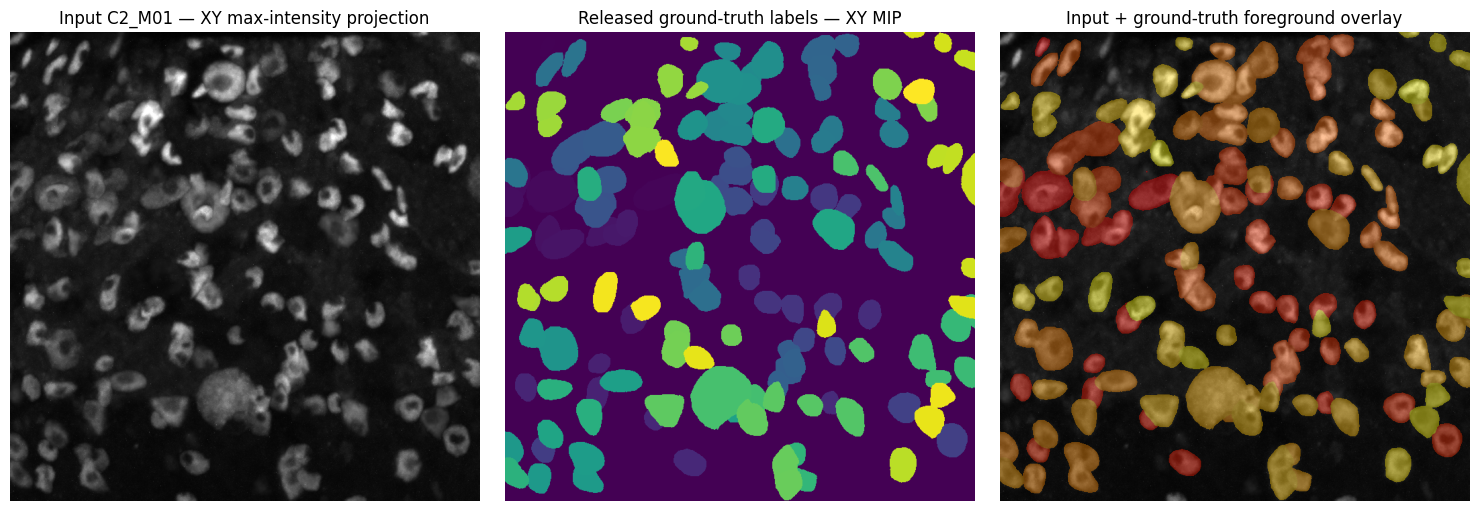

saved /content/nucverse3d_input_preview.png


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tifffile import imread

IMG = "/content/NucVerse3D/data/raw/6_Drosophila_denoised/test/images/C2_M01.tif"
MSK = "/content/NucVerse3D/data/raw/6_Drosophila_denoised/test/masks/C2_M01-label.tif"
img = imread(IMG)
msk = imread(MSK)
print("image:", img.shape, img.dtype, "range", float(img.min()), "-", float(img.max()))
print("mask:", msk.shape, msk.dtype, "ground-truth instances:", len(np.unique(msk)) - (1 if msk.min() == 0 else 0))

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(img.max(axis=0), cmap="gray")
axes[0].set_title("Input C2_M01 — XY max-intensity projection")
axes[1].imshow(msk.max(axis=0), cmap="viridis")
axes[1].set_title("Released ground-truth labels — XY MIP")
axes[2].imshow(img.max(axis=0), cmap="gray")
axes[2].imshow(np.ma.masked_where(msk.max(axis=0) == 0, msk.max(axis=0)), cmap="autumn", alpha=0.4)
axes[2].set_title("Input + ground-truth foreground overlay")
for ax in axes:
    ax.set_axis_off()
plt.tight_layout()
plt.savefig("/content/nucverse3d_input_preview.png", dpi=80)
plt.show()
print("saved /content/nucverse3d_input_preview.png")

## 7. Run the author's prediction pipeline (unmodified)

Run exactly what the paper's README documents for a dataset-specific model:

```
python -m nuclei_prediction resunet_drosophila-denoised data/raw/6_Drosophila_denoised/test/images
```

This uses the pinned `src/config.py` hyperparameters: uneven-illumination correction +
per-slice blind deconvolution (author default `PREPROCESSING_ENABLED=True`), percentile
normalization, (64,128,128) patches at step (48,96,96), batch size 2, then gradient-descent
voxel grouping (200 iterations), centroid seeding and KD-tree label assignment. Outputs:
`results/resunet_drosophila-denoised/6_Drosophila_denoised/C2_M01/{C2_M01_labels,C2_M01_binary}.tif`.
Only `C2_M01` was extracted, so the pipeline runs on that single volume. Progress streams below.
**期待される結果**: パッチ予測 → 勾配場 → インスタンス再構築が進行し、終了コード 0 で完了する。

In [ ]:
import subprocess, sys, time

t0 = time.time()
cmd = [sys.executable, "-u", "-m", "nuclei_prediction",
       "resunet_drosophila-denoised",
       "data/raw/6_Drosophila_denoised/test/images"]
proc = subprocess.Popen(cmd, cwd="/content/NucVerse3D",
                        stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True, bufsize=1)
assert proc.stdout is not None
for line in proc.stdout:
    print(line, end="")
proc.wait(timeout=4 * 3600)
print(f"\nexit code: {proc.returncode}  wall time: {time.time() - t0:.0f} s")
assert proc.returncode == 0, "author prediction pipeline failed"
RESULTS = "/content/NucVerse3D/results/resunet_drosophila-denoised/6_Drosophila_denoised/C2_M01"
print(sorted(os.listdir(RESULTS)))

HERE:  /content/NucVerse3D/results  -> /content/NucVerse3D/results


HERE NOW:  /content/NucVerse3D/results  -> /content/NucVerse3D/results  , resunet_drosophila-denoised  , C2_M01 2
Saving data prediction  at:  /content/NucVerse3D/results/resunet_drosophila-denoised/6_Drosophila_denoised/C2_M01
Directory created successfully!


  100% Deconvolucion: ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53/53 0:00:30 < 0:00:00


img_patches_reshaped:  49


tiles: 1

  0%|          | 0/49 [00:00<?, ?it/s] Processed elements from 0 to 1. Remaining elements: 49


...

 98%|█████████▊| 196/200 [01:30<00:01,  2.42it/s]


 98%|█████████▊| 197/200 [01:30<00:01,  2.45it/s]


 99%|█████████▉| 198/200 [01:31<00:00,  2.43it/s]


100%|██████████| 200/200 [01:31<00:00,  2.18it/s]



exit code: 0  wall time: 277 s
['C2_M01_binary.tif', 'C2_M01_labels.tif']


## 8. Compare with the released ground truth (AI-written helper)

The repository ships no evaluation script, so this matching helper was written for this
reproduction (AI-generated; not author code). It performs a **one-to-one greedy matching** between
predicted and ground-truth instances at IoU ≥ 0.5 and reports precision, recall and F1 — a simplified
stand-in for the paper's AP metrics, sufficient to check that the released checkpoint reproduces
sensible segmentation on this sample. Nucleus **counts** are also compared.
**期待される結果**: GT 核数と予測核数、IoU 0.5 での precision / recall / F1 の表。

In [ ]:
import numpy as np
import pandas as pd
from tifffile import imread

def match_instances(gt, pred, iou_thresh=0.5):
    """AI-written one-to-one greedy IoU matching. Returns (tp, n_gt, n_pred, matched_pairs)."""
    gt_ids = np.unique(gt); gt_ids = gt_ids[gt_ids > 0]
    pr_ids = np.unique(pred); pr_ids = pr_ids[pr_ids > 0]
    n_gt, n_pr = len(gt_ids), len(pr_ids)
    gt_index = {v: i for i, v in enumerate(gt_ids)}
    pr_index = {v: i for i, v in enumerate(pr_ids)}
    both = (gt > 0) & (pred > 0)
    inter = np.zeros((n_gt, n_pr), dtype=np.int64)
    g, p = gt[both], pred[both]
    gi = np.fromiter((gt_index[v] for v in g), dtype=np.int64, count=len(g))
    pi = np.fromiter((pr_index[v] for v in p), dtype=np.int64, count=len(p))
    np.add.at(inter, (gi, pi), 1)
    gt_area = np.array([(gt == v).sum() for v in gt_ids], dtype=np.int64)
    pr_area = np.array([(pred == v).sum() for v in pr_ids], dtype=np.int64)
    union = gt_area[:, None] + pr_area[None, :] - inter
    iou = np.where(union > 0, inter / union, 0.0)
    matched_gt, matched_pr, pairs = set(), set(), []
    order = np.unravel_index(np.argsort(-iou, axis=None), iou.shape)
    for gi_, pi_ in zip(*order):
        if iou[gi_, pi_] < iou_thresh:
            break
        if gi_ in matched_gt or pi_ in matched_pr:
            continue
        matched_gt.add(gi_); matched_pr.add(pi_)
        pairs.append((int(gt_ids[gi_]), int(pr_ids[pi_]), float(iou[gi_, pi_])))
    return len(pairs), n_gt, n_pr, pairs

pred_labels = imread(RESULTS + "/C2_M01_labels.tif")
pred_binary = imread(RESULTS + "/C2_M01_binary.tif")
print("predicted labels:", pred_labels.shape, pred_labels.dtype)
tp, n_gt, n_pr, pairs = match_instances(msk, pred_labels, 0.5)
precision = tp / n_pr if n_pr else 0.0
recall = tp / n_gt if n_gt else 0.0
f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0
iou_vals = [p[2] for p in pairs]
results = pd.DataFrame([
    {"metric": "ground-truth instances", "value": n_gt},
    {"metric": "predicted instances", "value": n_pr},
    {"metric": "true positives (IoU>=0.5, one-to-one)", "value": tp},
    {"metric": "precision @ IoU 0.5", "value": round(precision, 3)},
    {"metric": "recall @ IoU 0.5", "value": round(recall, 3)},
    {"metric": "F1 @ IoU 0.5", "value": round(f1, 3)},
    {"metric": "mean matched IoU", "value": round(float(np.mean(iou_vals)), 3) if iou_vals else None},
])
results

predicted labels: (53, 700, 700) uint16


,metric,value
0,ground-truth instances,154.000
1,predicted instances,154.000
2,"true positives (IoU>=0.5, one-to-one)",99.000
3,precision @ IoU 0.5,0.643
4,recall @ IoU 0.5,0.643
5,F1 @ IoU 0.5,0.643
6,mean matched IoU,0.646


## 9. Side-by-side result visualization

Render MIPs of the ground-truth annotation and the model's predicted instance labels for the
same volume, plus the input with the predicted foreground contour. All images come from this run's outputs.
**期待される結果**: 正解ラベルと予測ラベル、入力＋予測輪郭の並比較画像。

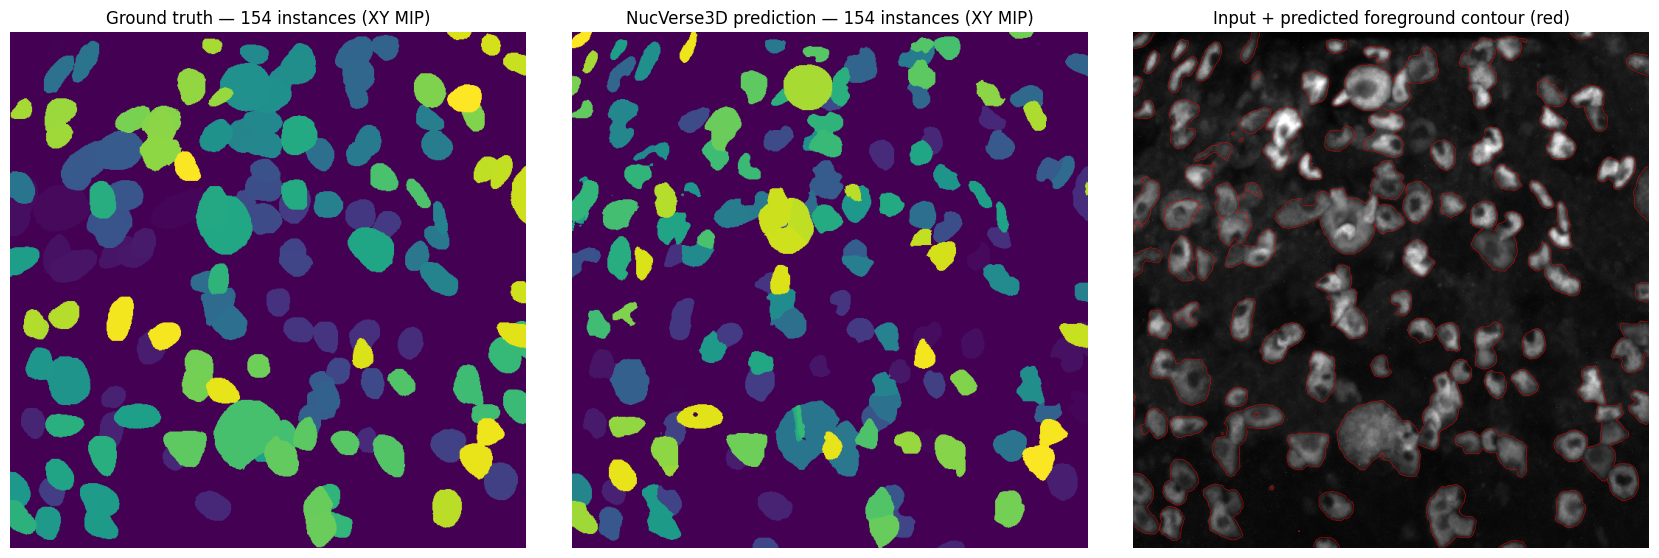

saved /content/nucverse3d_prediction_vs_gt.png


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5.5))
axes[0].imshow(msk.max(axis=0), cmap="viridis")
axes[0].set_title(f"Ground truth — {n_gt} instances (XY MIP)")
axes[1].imshow(pred_labels.max(axis=0), cmap="viridis")
axes[1].set_title(f"NucVerse3D prediction — {n_pr} instances (XY MIP)")
axes[2].imshow(img.max(axis=0), cmap="gray")
axes[2].contour(pred_binary.max(axis=0) > 0, levels=[0.5], colors="red", linewidths=0.3)
axes[2].set_title("Input + predicted foreground contour (red)")
for ax in axes:
    ax.set_axis_off()
plt.tight_layout()
plt.savefig("/content/nucverse3d_prediction_vs_gt.png", dpi=80)
plt.show()
print("saved /content/nucverse3d_prediction_vs_gt.png")

## 10. Export the metrics

Write the small metrics table to CSV inside the Colab VM (`/content`) so learners can download it.
**期待される結果**: CSV ファイルのパスと内容が表示される。

In [ ]:
out_csv = "/content/nucverse3d_c2_m01_metrics.csv"
results.to_csv(out_csv, index=False)
print(open(out_csv).read())

metric,value
ground-truth instances,154.0
predicted instances,154.0
"true positives (IoU>=0.5, one-to-one)",99.0
precision @ IoU 0.5,0.643
recall @ IoU 0.5,0.643
F1 @ IoU 0.5,0.643
mean matched IoU,0.646



## Interpretation, limitations, and validation record

* What this run shows: the released `resunet_drosophila-denoised` checkpoint and the author's
  unmodified prediction pipeline segment the held-out `C2_M01` volume into instances comparable with
  the released annotation (exact counts/metrics are in the outputs above, produced on the recorded
  runtime — not pre-stated here).
* What it does **not** show: the paper's dataset-level AP/precision/recall benchmarks (2 test
  volumes, 6 datasets), the generalized-model comparisons, ablations, or NDS phenotyping. A
  one-example run cannot verify published accuracy levels.
* Adaptations: dependency installation adapted to Colab's Python/TF (weights are Keras-3 format);
  `raw.zip`/`models.zip` read selectively over HTTP range requests (size-checked; archive md5 not
  computable in that mode — a full-download fallback with md5 checks is included as comments). No
  scientific parameter was altered; the prediction ran via the author's CLI entry point.
* Provenance: code pinned at `d809a2e6cf380342708b7a9107574b259e6b34eb` (MIT); data/weights from
  Zenodo record 18517324 v1.0; paper doi:10.1038/s41598-026-51994-x (bioRxiv v2
  10.64898/2026.02.05.704108). NucVerse3D method: residual attention 3D U-Net with a reversible
  gradient-field representation (paper Methods; `src/keras_models/attention_unet_3d.py`,
  `src/nuclei_prediction.py`).
* 日本語: 本ノートブックは学習済みモデルによる 1 サンプルの推論再現です。論文のデータセット全体の
  精度指標（AP 等）の検証ではありません。評価指標は AI が追加した簡易マッチング（IoU 0.5 の 1 対 1
  グリーディマッチング）であり、著者実装ではありません。